# v1.1 Population Methodology

This notebook defines the population methodology for Seattle Public Safety
Dashboard v1.1.

## Goals

We need defensible population denominators for:

1. Seattle citywide crime rates.
2. Crime rates for each SPD MCPP neighborhood.
3. Neighborhood comparisons and rankings.
4. Future current-vs-previous period comparisons.

## Geography problem

The dashboard uses SPD Micro-Community Policing Plan (MCPP) neighborhoods.

MCPP neighborhoods are not Census geographies and should not be assumed to
match Seattle Community Reporting Areas or commonly used neighborhood
boundaries.

Therefore, Census population estimates must be translated onto the MCPP
geography.

## Candidate methodology

Neighborhood population:

2024 ACS 5-Year block-group population
        ↓
2020 Census block population weights
        ↓
estimated 2024 population by Census block
        ↓
assign Census blocks to MCPP neighborhoods
        ↓
aggregate into MCPP population estimates

Citywide population:

- 2024 ACS 5-Year Seattle population for consistency with neighborhood rates.
- 2026 Washington OFM official Seattle population as the current official
  citywide population estimate.

The notebook will determine whether the MCPP estimates should be calibrated
to the ACS Seattle city total before production use.

In [1]:
from pathlib import Path
import os
import sys

import geopandas as gpd
import numpy as np
import pandas as pd
import requests
from dotenv import load_dotenv
from IPython.display import display


# -------------------------------------------------------------------
# Locate repository root.
# -------------------------------------------------------------------

cwd = Path.cwd().resolve()

REPO_ROOT = next(
    (
        path
        for path in [cwd, *cwd.parents]
        if (path / "dashboard").is_dir()
        and (path / "app.py").exists()
    ),
    None,
)

if REPO_ROOT is None:
    raise RuntimeError(
        "Could not locate repository root. "
        "Expected app.py and dashboard/."
    )

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print(f"Repository root: {REPO_ROOT}")


# -------------------------------------------------------------------
# Load repository environment variables.
# -------------------------------------------------------------------

ENV_PATH = REPO_ROOT / ".env"

load_dotenv(ENV_PATH)

print(f".env file found: {ENV_PATH.exists()}")


# -------------------------------------------------------------------
# Project imports.
# -------------------------------------------------------------------

from dashboard.crime_dashboard_data import (
    load_crime_dashboard_context,
    normalize_neighborhood_name,
)


# -------------------------------------------------------------------
# Source constants.
# -------------------------------------------------------------------

ACS_YEAR = 2024

STATE_FIPS = "53"
KING_COUNTY_FIPS = "033"
SEATTLE_PLACE_FIPS = "63000"

ACS_POPULATION_VARIABLE = "B01003_001E"
ACS_POPULATION_MOE_VARIABLE = "B01003_001M"

CENSUS_API_KEY = os.getenv("CENSUS_API_KEY")

ACS_API_URL = (
    f"https://api.census.gov/data/"
    f"{ACS_YEAR}/acs/acs5"
)

DECENNIAL_PL_API_URL = (
    "https://api.census.gov/data/2020/dec/pl"
)

TIGER_2020_BLOCK_URL = (
    "https://www2.census.gov/geo/tiger/"
    "TIGER2020/TABBLOCK20/"
    "tl_2020_53_tabblock20.zip"
)


# -------------------------------------------------------------------
# Current official Seattle population.
#
# Washington OFM April 1, 2026 official estimate.
# -------------------------------------------------------------------

OFM_SEATTLE_POPULATION_2026 = 823_400
OFM_ESTIMATE_DATE = pd.Timestamp("2026-04-01")


# -------------------------------------------------------------------
# Cache large Census geography outside the repository.
# -------------------------------------------------------------------

CACHE_DIR = (
    Path.home()
    / ".cache"
    / "spd_dashboard_population"
)

CACHE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

BLOCK_ZIP_PATH = (
    CACHE_DIR
    / "tl_2020_53_tabblock20.zip"
)


# -------------------------------------------------------------------
# Load current dashboard geography.
# -------------------------------------------------------------------

crime_context = (
    load_crime_dashboard_context()
)

mcpp = (
    crime_context["mcpp_boundaries"]
    .copy()
)

pd.set_option(
    "display.max_columns",
    50,
)

pd.set_option(
    "display.max_rows",
    100,
)


# -------------------------------------------------------------------
# Basic setup checks.
# -------------------------------------------------------------------

print()
print(
    "Census API key available:",
    bool(CENSUS_API_KEY),
)

print(
    "MCPP polygons:",
    len(mcpp),
)

Repository root: C:\Users\benca\code\PersonalPythonProjects\SPDCallDashboard
.env file found: True

Census API key available: True
MCPP polygons: 58


In [2]:
print("MCPP GEOGRAPHY")
print("=" * 60)

print("CRS:", mcpp.crs)

print(
    "Polygon count:",
    len(mcpp),
)

print(
    "Invalid geometries:",
    (~mcpp.geometry.is_valid).sum(),
)

print(
    "Missing geometries:",
    mcpp.geometry.isna().sum(),
)

print()


mcpp_names = (
    mcpp[
        "mcpp_neighborhood"
    ]
    .astype("string")
    .sort_values()
    .reset_index(drop=True)
)

display(
    mcpp_names.to_frame(
        name="mcpp_neighborhood"
    )
)


duplicates = (
    mcpp[
        "mcpp_neighborhood"
    ]
    .value_counts()
    .loc[
        lambda s: s > 1
    ]
)

print()
print(
    "Duplicate MCPP names:",
    len(duplicates),
)

if not duplicates.empty:
    display(duplicates)

MCPP GEOGRAPHY
CRS: EPSG:4326
Polygon count: 58
Invalid geometries: 0
Missing geometries: 0



,mcpp_neighborhood
0,alaska junction
1,alki
2,ballard north
3,ballard south
4,belltown
5,bitterlake
6,brighton/dunlap
7,capitol hill
8,central area/squire park
9,chinatown/international district



Duplicate MCPP names: 0


## Geography decision

Population estimates must be generated for the same MCPP geography used by the
crime dashboard.

Seattle Community Reporting Areas are useful external references, but they are
not interchangeable with MCPP neighborhoods.

The population pipeline should therefore use the actual MCPP boundary polygons
loaded by the dashboard rather than attempting a neighborhood-name crosswalk.

In [3]:
if not CENSUS_API_KEY:
    raise RuntimeError(
        "CENSUS_API_KEY is not available. "
        "Set it in your local environment before "
        "running Census API cells."
    )


def census_get(
    base_url,
    *,
    get,
    for_clause,
    in_clause=None,
):
    params = {
        "get": get,
        "for": for_clause,
        "key": CENSUS_API_KEY,
    }

    if in_clause is not None:
        params["in"] = in_clause

    response = requests.get(
        base_url,
        params=params,
        timeout=60,
    )

    response.raise_for_status()

    payload = response.json()

    if len(payload) < 2:
        raise ValueError(
            "Census API returned no data rows."
        )

    return pd.DataFrame(
        payload[1:],
        columns=payload[0],
    )


print("Census API helper ready.")

Census API helper ready.


In [4]:
acs_bg = census_get(
    ACS_API_URL,
    get=(
        "NAME,"
        f"{ACS_POPULATION_VARIABLE},"
        f"{ACS_POPULATION_MOE_VARIABLE}"
    ),
    for_clause="block group:*",
    in_clause=(
        f"state:{STATE_FIPS} "
        f"county:{KING_COUNTY_FIPS} "
        "tract:*"
    ),
)


acs_bg["population"] = pd.to_numeric(
    acs_bg[
        ACS_POPULATION_VARIABLE
    ],
    errors="coerce",
)

acs_bg["population_moe"] = (
    pd.to_numeric(
        acs_bg[
            ACS_POPULATION_MOE_VARIABLE
        ],
        errors="coerce",
    )
)

acs_bg["bg_geoid"] = (
    acs_bg["state"]
    + acs_bg["county"]
    + acs_bg["tract"]
    + acs_bg["block group"]
)


print(
    "ACS block groups returned:",
    len(acs_bg),
)

print(
    "Missing population estimates:",
    acs_bg[
        "population"
    ].isna().sum(),
)

print(
    "King County ACS population sum:",
    f"{acs_bg['population'].sum():,.0f}",
)

display(
    acs_bg.head()
)


ACS block groups returned: 1545
Missing population estimates: 0
King County ACS population sum: 2,287,171


,NAME,B01003_001E,B01003_001M,state,county,tract,block group,population,population_moe,bg_geoid
0,Block Group 1; Census Tract 1.01; King County;...,1399,624,53,033,000101,1,1399,624,530330001011
1,Block Group 2; Census Tract 1.01; King County;...,1199,237,53,033,000101,2,1199,237,530330001012
2,Block Group 3; Census Tract 1.01; King County;...,819,270,53,033,000101,3,819,270,530330001013
3,Block Group 1; Census Tract 1.02; King County;...,1653,779,53,033,000102,1,1653,779,530330001021
4,Block Group 2; Census Tract 1.02; King County;...,1161,386,53,033,000102,2,1161,386,530330001022


In [5]:
acs_seattle = census_get(
    ACS_API_URL,
    get=(
        "NAME,"
        f"{ACS_POPULATION_VARIABLE},"
        f"{ACS_POPULATION_MOE_VARIABLE}"
    ),
    for_clause=(
        f"place:{SEATTLE_PLACE_FIPS}"
    ),
    in_clause=(
        f"state:{STATE_FIPS}"
    ),
)


acs_seattle["population"] = (
    pd.to_numeric(
        acs_seattle[
            ACS_POPULATION_VARIABLE
        ],
        errors="coerce",
    )
)

acs_seattle[
    "population_moe"
] = pd.to_numeric(
    acs_seattle[
        ACS_POPULATION_MOE_VARIABLE
    ],
    errors="coerce",
)


ACS_SEATTLE_POPULATION = int(
    acs_seattle.iloc[0][
        "population"
    ]
)


print(
    "2024 ACS 5-Year Seattle population:",
    f"{ACS_SEATTLE_POPULATION:,}",
)

print(
    "2026 OFM official Seattle population:",
    f"{OFM_SEATTLE_POPULATION_2026:,}",
)

print(
    "Difference:",
    f"{OFM_SEATTLE_POPULATION_2026 - ACS_SEATTLE_POPULATION:,}",
)

print(
    "Difference (%):",
    (
        (
            OFM_SEATTLE_POPULATION_2026
            / ACS_SEATTLE_POPULATION
            - 1
        )
        * 100
    ),
)

2024 ACS 5-Year Seattle population: 754,195
2026 OFM official Seattle population: 823,400
Difference: 69,205
Difference (%): 9.176008857125817


## Why use 2020 Census blocks?

ACS block-group population cannot be assigned directly to an MCPP neighborhood
when a block group crosses an MCPP boundary.

A simple area-weighted split would implicitly assume people are distributed
uniformly throughout the block group. That is especially problematic in
Seattle because industrial areas, parks, water, and dense residential areas can
exist inside the same larger Census geography.

Instead:

1. Get the exact 2020 Census population of each Census block.
2. Calculate each block's share of its parent block group's 2020 population.
3. Apply that share to the block group's 2024 ACS population estimate.
4. Assign each small block to an MCPP neighborhood.

This is a population-weighted interpolation.

Important limitation:

The method assumes the within-block-group population distribution in 2024 is
approximately proportional to its 2020 distribution.

The notebook will identify block groups where that assumption cannot be used,
such as a 2020 zero-population block group with a positive 2024 ACS estimate.

In [6]:
blocks_population = census_get(
    DECENNIAL_PL_API_URL,
    get="NAME,P1_001N",
    for_clause="block:*",
    in_clause=(
        f"state:{STATE_FIPS} "
        f"county:{KING_COUNTY_FIPS} "
        "tract:*"
    ),
)


blocks_population[
    "population_2020"
] = pd.to_numeric(
    blocks_population[
        "P1_001N"
    ],
    errors="coerce",
)


blocks_population[
    "block_geoid"
] = (
    blocks_population["state"]
    + blocks_population["county"]
    + blocks_population["tract"]
    + blocks_population["block"]
)


# A Census block group's GEOID is:
#
# state + county + tract + first digit of block number

blocks_population[
    "bg_geoid"
] = (
    blocks_population[
        "block_geoid"
    ]
    .str[:12]
)


print(
    "King County Census blocks:",
    f"{len(blocks_population):,}",
)

print(
    "2020 King County population:",
    f"{blocks_population['population_2020'].sum():,.0f}",
)

print(
    "Zero-population blocks:",
    (
        blocks_population[
            "population_2020"
        ]
        == 0
    ).sum(),
)

display(
    blocks_population.head()
)

King County Census blocks: 27,686
2020 King County population: 2,269,675
Zero-population blocks: 6150


,NAME,P1_001N,state,county,tract,block,population_2020,block_geoid,bg_geoid
0,"Block 1000, Block Group 1, Census Tract 1.01, ...",74,53,033,000101,1000,74,530330001011000,530330001011
1,"Block 1001, Block Group 1, Census Tract 1.01, ...",99,53,033,000101,1001,99,530330001011001,530330001011
2,"Block 1002, Block Group 1, Census Tract 1.01, ...",289,53,033,000101,1002,289,530330001011002,530330001011
3,"Block 1004, Block Group 1, Census Tract 1.01, ...",54,53,033,000101,1004,54,530330001011004,530330001011
4,"Block 1005, Block Group 1, Census Tract 1.01, ...",649,53,033,000101,1005,649,530330001011005,530330001011


In [7]:
def download_file(
    url,
    destination,
    chunk_size=1024 * 1024,
):
    destination = Path(destination)

    if destination.exists():
        print(
            "Using cached file:",
            destination,
        )

        return destination

    print(
        "Downloading:",
        url,
    )

    with requests.get(
        url,
        stream=True,
        timeout=120,
    ) as response:

        response.raise_for_status()

        with destination.open(
            "wb"
        ) as file:

            for chunk in response.iter_content(
                chunk_size=chunk_size
            ):
                if chunk:
                    file.write(chunk)

    print(
        "Saved:",
        destination,
    )

    return destination


download_file(
    TIGER_2020_BLOCK_URL,
    BLOCK_ZIP_PATH,
)

Downloading: https://www2.census.gov/geo/tiger/TIGER2020/TABBLOCK20/tl_2020_53_tabblock20.zip
Saved: C:\Users\benca\.cache\spd_dashboard_population\tl_2020_53_tabblock20.zip


WindowsPath('C:/Users/benca/.cache/spd_dashboard_population/tl_2020_53_tabblock20.zip')

In [8]:
# Convert the MCPP extent to the Census block CRS.
#
# TIGER 2020 blocks use NAD83 / EPSG:4269.

mcpp_4269 = (
    mcpp
    .to_crs(
        epsg=4269
    )
)

bbox = tuple(
    mcpp_4269.total_bounds
)


blocks_geo = gpd.read_file(
    f"zip://{BLOCK_ZIP_PATH}",
    bbox=bbox,
)


# Defensive county filter.

if "COUNTYFP20" in blocks_geo.columns:
    blocks_geo = (
        blocks_geo[
            blocks_geo[
                "COUNTYFP20"
            ]
            == KING_COUNTY_FIPS
        ]
        .copy()
    )


blocks_geo = (
    blocks_geo
    .rename(
        columns={
            "GEOID20": (
                "block_geoid"
            )
        }
    )
)


print(
    "Block geometries in Seattle extent:",
    f"{len(blocks_geo):,}",
)

print(
    "CRS:",
    blocks_geo.crs,
)

print(
    "Invalid geometries:",
    (~blocks_geo.geometry.is_valid).sum(),
)

Block geometries in Seattle extent: 11,198
CRS: EPSG:4269
Invalid geometries: 0


In [9]:
blocks = (
    blocks_geo[
        [
            "block_geoid",
            "geometry",
        ]
    ]
    .merge(
        blocks_population[
            [
                "block_geoid",
                "bg_geoid",
                "population_2020",
            ]
        ],
        on="block_geoid",
        how="left",
        validate="one_to_one",
    )
)


print(
    "Block geometries:",
    len(blocks),
)

print(
    "Missing 2020 population:",
    blocks[
        "population_2020"
    ].isna().sum(),
)


if blocks[
    "population_2020"
].isna().any():

    display(
        blocks.loc[
            blocks[
                "population_2020"
            ].isna(),
            [
                "block_geoid",
                "bg_geoid",
            ],
        ].head(50)
    )

Block geometries: 11198
Missing 2020 population: 0


In [10]:
# Work in a projected CRS when creating representative points.

PROJECTED_CRS = "EPSG:2285"


blocks_projected = (
    blocks
    .to_crs(
        PROJECTED_CRS
    )
)


block_points = (
    blocks_projected[
        [
            "block_geoid",
            "bg_geoid",
            "population_2020",
            "geometry",
        ]
    ]
    .copy()
)


block_points[
    "geometry"
] = (
    block_points
    .geometry
    .representative_point()
)


mcpp_projected = (
    mcpp
    .to_crs(
        PROJECTED_CRS
    )
)


block_mcpp = (
    gpd.sjoin(
        block_points,
        mcpp_projected[
            [
                "mcpp_neighborhood",
                "geometry",
            ]
        ],
        how="inner",
        predicate="within",
    )
    .drop(
        columns=[
            "index_right",
        ],
        errors="ignore",
    )
)


print(
    "Blocks assigned to MCPP:",
    f"{len(block_mcpp):,}",
)

print(
    "2020 population represented:",
    f"{block_mcpp['population_2020'].sum():,.0f}",
)

print(
    "MCPP neighborhoods represented:",
    block_mcpp[
        "mcpp_neighborhood"
    ].nunique(),
)

Blocks assigned to MCPP: 10,237
2020 population represented: 737,015
MCPP neighborhoods represented: 58


In [11]:
bg_population_2020 = (
    blocks_population
    .groupby(
        "bg_geoid",
        as_index=False,
    )
    .agg(
        bg_population_2020=(
            "population_2020",
            "sum",
        )
    )
)


block_mcpp = (
    block_mcpp
    .merge(
        bg_population_2020,
        on="bg_geoid",
        how="left",
        validate="many_to_one",
    )
)


block_mcpp[
    "population_weight"
] = np.where(
    block_mcpp[
        "bg_population_2020"
    ]
    > 0,

    block_mcpp[
        "population_2020"
    ]
    / block_mcpp[
        "bg_population_2020"
    ],

    np.nan,
)


display(
    block_mcpp[
        [
            "block_geoid",
            "bg_geoid",
            "mcpp_neighborhood",
            "population_2020",
            "bg_population_2020",
            "population_weight",
        ]
    ].head()
)

,block_geoid,bg_geoid,mcpp_neighborhood,population_2020,bg_population_2020,population_weight
0,530330088003006,530330088003,central area/squire park,62,1093,0.056725
1,530330088002002,530330088002,central area/squire park,25,1301,0.019216
2,530330078003025,530330078003,madrona/leschi,50,1160,0.043103
3,530330018002008,530330018002,greenwood,68,1690,0.040237
4,530330114012006,530330114012,roxhill/westwood/arbor heights,67,1331,0.050338


In [12]:
block_mcpp = (
    block_mcpp
    .merge(
        acs_bg[
            [
                "bg_geoid",
                "population",
                "population_moe",
            ]
        ].rename(
            columns={
                "population": (
                    "acs_bg_population_2024"
                ),
                "population_moe": (
                    "acs_bg_population_moe_2024"
                ),
            }
        ),
        on="bg_geoid",
        how="left",
        validate="many_to_one",
    )
)


missing_acs_bg = (
    block_mcpp[
        "acs_bg_population_2024"
    ].isna()
)


print(
    "Seattle-area blocks with no matching "
    "2024 ACS block group:",
    missing_acs_bg.sum(),
)

print(
    "2020 population in unmatched blocks:",
    block_mcpp.loc[
        missing_acs_bg,
        "population_2020",
    ].sum(),
)


if missing_acs_bg.any():
    display(
        block_mcpp.loc[
            missing_acs_bg,
            [
                "block_geoid",
                "bg_geoid",
                "mcpp_neighborhood",
                "population_2020",
            ],
        ]
        .head(100)
    )

Seattle-area blocks with no matching 2024 ACS block group: 0
2020 population in unmatched blocks: 0


In [13]:
problem_bg = (
    block_mcpp[
        (
            block_mcpp[
                "bg_population_2020"
            ]
            <= 0
        )
        & (
            block_mcpp[
                "acs_bg_population_2024"
            ]
            > 0
        )
    ]
    [
        [
            "bg_geoid",
            "acs_bg_population_2024",
            "mcpp_neighborhood",
        ]
    ]
    .drop_duplicates()
)


print(
    "ACS-positive block groups with zero "
    "2020 population denominator:",
    len(problem_bg),
)


if not problem_bg.empty:
    display(problem_bg)

ACS-positive block groups with zero 2020 population denominator: 0


In [14]:
block_mcpp[
    "estimated_population_2024"
] = (
    block_mcpp[
        "acs_bg_population_2024"
    ]
    * block_mcpp[
        "population_weight"
    ]
)


print(
    "Estimated 2024 population assigned "
    "to MCPP blocks:",
    f"{block_mcpp['estimated_population_2024'].sum():,.1f}",
)

Estimated 2024 population assigned to MCPP blocks: 754,130.6


In [15]:
mcpp_population_raw = (
    block_mcpp
    .groupby(
        "mcpp_neighborhood",
        as_index=False,
    )
    .agg(
        population_2024_raw=(
            "estimated_population_2024",
            "sum",
        ),
        census_blocks=(
            "block_geoid",
            "nunique",
        ),
        source_block_groups=(
            "bg_geoid",
            "nunique",
        ),
    )
)


mcpp_population_raw[
    "population_2024_raw"
] = (
    mcpp_population_raw[
        "population_2024_raw"
    ]
    .round()
    .astype(int)
)


mcpp_population_raw = (
    mcpp_population_raw
    .sort_values(
        "population_2024_raw",
        ascending=False,
    )
    .reset_index(drop=True)
)


display(
    mcpp_population_raw
)

,mcpp_neighborhood,population_2024_raw,census_blocks,source_block_groups
0,queen anne,48470,648,38
1,sandpoint,38446,574,30
2,northgate,38236,381,29
3,university,32532,252,28
4,roosevelt/ravenna,32127,493,31
5,capitol hill,32033,251,25
6,ballard north,30348,412,25
7,ballard south,26046,336,25
8,slu/cascade,25462,191,23
9,lakecity,25296,269,24


In [16]:
raw_mcpp_total = (
    mcpp_population_raw[
        "population_2024_raw"
    ].sum()
)


difference = (
    raw_mcpp_total
    - ACS_SEATTLE_POPULATION
)


pct_difference = (
    difference
    / ACS_SEATTLE_POPULATION
    * 100
)


reconciliation = pd.DataFrame(
    {
        "population_measure": [
            (
                "Raw reconstructed "
                "MCPP population"
            ),
            (
                "2024 ACS Seattle city"
            ),
            (
                "2026 OFM Seattle city"
            ),
        ],
        "population": [
            raw_mcpp_total,
            ACS_SEATTLE_POPULATION,
            OFM_SEATTLE_POPULATION_2026,
        ],
    }
)


display(reconciliation)


print()
print(
    "Raw MCPP minus ACS city:",
    f"{difference:+,.0f}",
)

print(
    "Difference from ACS city:",
    f"{pct_difference:+.3f}%",
)

,population_measure,population
0,Raw reconstructed MCPP population,754133
1,2024 ACS Seattle city,754195
2,2026 OFM Seattle city,823400



Raw MCPP minus ACS city: -62
Difference from ACS city: -0.008%


In [17]:
OLD_POPULATION_PATH = (
    REPO_ROOT
    / "data"
    / "external"
    / "neighborhood_population.csv"
)


old_population = pd.read_csv(
    OLD_POPULATION_PATH
)


old_population[
    "mcpp_neighborhood"
] = normalize_neighborhood_name(
    old_population[
        "dispatch_neighborhood"
    ]
)


old_population[
    "population"
] = pd.to_numeric(
    old_population[
        "population"
    ],
    errors="coerce",
)


old_population = (
    old_population[
        [
            "mcpp_neighborhood",
            "population",
        ]
    ]
    .rename(
        columns={
            "population": (
                "old_population"
            )
        }
    )
)


population_comparison = (
    mcpp_population_raw
    .merge(
        old_population,
        on="mcpp_neighborhood",
        how="outer",
    )
)


population_comparison[
    "raw_difference"
] = (
    population_comparison[
        "population_2024_raw"
    ]
    - population_comparison[
        "old_population"
    ]
)


population_comparison[
    "pct_difference"
] = (
    population_comparison[
        "raw_difference"
    ]
    / population_comparison[
        "old_population"
    ]
    * 100
)


display(
    population_comparison
    .sort_values(
        "pct_difference",
        key=lambda s: s.abs(),
        ascending=False,
        na_position="last",
    )
)


print()
print(
    "Old static population total:",
    f"{old_population['old_population'].sum():,.0f}",
)

print(
    "New raw MCPP estimate total:",
    f"{raw_mcpp_total:,.0f}",
)

,mcpp_neighborhood,population_2024_raw,census_blocks,source_block_groups,old_population,raw_difference,pct_difference
13,commercial harbor island,3,35,1,0,3,inf
50,sandpoint,38446,574,30,6105,32341,529.746110
35,morgan,13788,197,14,4210,9578,227.505938
2,ballard north,30348,412,25,10750,19598,182.306977
33,miller park,8282,100,6,2980,5302,177.919463
31,magnolia,23839,452,17,9140,14699,160.820569
14,downtown commercial,9400,157,13,3840,5560,144.791667
5,bitterlake,18922,208,16,8110,10812,133.316893
51,slu/cascade,25462,191,23,11350,14112,124.334802
41,northgate,38236,381,29,18720,19516,104.252137



Old static population total: 570,655
New raw MCPP estimate total: 754,133


In [18]:
ACS_CALIBRATION_FACTOR = (
    ACS_SEATTLE_POPULATION
    / raw_mcpp_total
)


mcpp_population = (
    mcpp_population_raw
    .copy()
)


mcpp_population[
    "population_2024_acs_calibrated"
] = (
    mcpp_population[
        "population_2024_raw"
    ]
    * ACS_CALIBRATION_FACTOR
)


mcpp_population[
    "population_2024_acs_calibrated"
] = (
    mcpp_population[
        "population_2024_acs_calibrated"
    ]
    .round()
    .astype(int)
)


print(
    "ACS city calibration factor:",
    ACS_CALIBRATION_FACTOR,
)

print(
    "Calibration adjustment:",
    f"{(ACS_CALIBRATION_FACTOR - 1) * 100:+.3f}%",
)

print(
    "Calibrated neighborhood sum:",
    f"{mcpp_population['population_2024_acs_calibrated'].sum():,}",
)

print(
    "ACS Seattle city population:",
    f"{ACS_SEATTLE_POPULATION:,}",
)


display(
    mcpp_population[
        [
            "mcpp_neighborhood",
            "population_2024_raw",
            "population_2024_acs_calibrated",
        ]
    ]
)

ACS city calibration factor: 1.0000822136148397
Calibration adjustment: +0.008%
Calibrated neighborhood sum: 754,194
ACS Seattle city population: 754,195


,mcpp_neighborhood,population_2024_raw,population_2024_acs_calibrated
0,queen anne,48470,48474
1,sandpoint,38446,38449
2,northgate,38236,38239
3,university,32532,32535
4,roosevelt/ravenna,32127,32130
5,capitol hill,32033,32036
6,ballard north,30348,30350
7,ballard south,26046,26048
8,slu/cascade,25462,25464
9,lakecity,25296,25298


In [19]:
OFM_SCALE_FACTOR = (
    OFM_SEATTLE_POPULATION_2026
    / ACS_SEATTLE_POPULATION
)


mcpp_population[
    "population_2026_uniform_ofm_scaled"
] = (
    mcpp_population[
        "population_2024_acs_calibrated"
    ]
    * OFM_SCALE_FACTOR
)


mcpp_population[
    "population_2026_uniform_ofm_scaled"
] = (
    mcpp_population[
        "population_2026_uniform_ofm_scaled"
    ]
    .round()
    .astype(int)
)


print(
    "ACS-to-OFM "
    "scaling ratio:",
    OFM_SCALE_FACTOR,
)

print(
    "Difference between OFM and ACS estimates:",
    f"{(OFM_SCALE_FACTOR - 1) * 100:.2f}%",
)


display(
    mcpp_population[
        [
            "mcpp_neighborhood",
            "population_2024_acs_calibrated",
            "population_2026_uniform_ofm_scaled",
        ]
    ]
)

ACS-to-OFM scaling ratio: 1.0917600885712582
Difference between OFM and ACS estimates: 9.18%


,mcpp_neighborhood,population_2024_acs_calibrated,population_2026_uniform_ofm_scaled
0,queen anne,48474,52922
1,sandpoint,38449,41977
2,northgate,38239,41748
3,university,32535,35520
4,roosevelt/ravenna,32130,35078
5,capitol hill,32036,34976
6,ballard north,30350,33135
7,ballard south,26048,28438
8,slu/cascade,25464,27801
9,lakecity,25298,27619


## Important interpretation of OFM scaling

Scaling every MCPP neighborhood by the Seattle-wide ACS-to-OFM scaling ratio
would force the neighborhood estimates to sum to the current OFM city total.

However, it applies the same cross-source scaling ratio to every neighborhood.

This ratio compares different statistical products and does not represent literal population growth.

Therefore, the uniformly OFM-scaled neighborhood values should be treated as a
sensitivity scenario, not automatically adopted as the production denominator.

A cleaner default may be:

- Neighborhood crime rates:
  2024 ACS-based MCPP estimates.

- Citywide crime rate:
  2024 ACS Seattle population when direct comparability with neighborhood
  rates is important.

- Current Seattle population context:
  2026 OFM official city population.

The final decision should depend on the reconciliation diagnostics above.

In [20]:
all_mcpp = set(
    normalize_neighborhood_name(
        mcpp[
            "mcpp_neighborhood"
        ]
    )
    .dropna()
)


estimated_mcpp = set(
    normalize_neighborhood_name(
        mcpp_population[
            "mcpp_neighborhood"
        ]
    )
    .dropna()
)


missing_population_neighborhoods = sorted(
    all_mcpp
    - estimated_mcpp
)


unexpected_population_neighborhoods = sorted(
    estimated_mcpp
    - all_mcpp
)


print(
    "MCPP polygons:",
    len(all_mcpp),
)

print(
    "MCPPs with population estimates:",
    len(estimated_mcpp),
)

print()
print(
    "Missing population neighborhoods:"
)

print(
    missing_population_neighborhoods
)

print()
print(
    "Unexpected population neighborhoods:"
)

print(
    unexpected_population_neighborhoods
)

MCPP polygons: 58
MCPPs with population estimates: 58

Missing population neighborhoods:
[]

Unexpected population neighborhoods:
[]


In [21]:
small_population = (
    mcpp_population[
        mcpp_population[
            "population_2024_acs_calibrated"
        ]
        < 500
    ]
    .copy()
)


display(
    small_population[
        [
            "mcpp_neighborhood",
            "population_2024_raw",
            "population_2024_acs_calibrated",
            "census_blocks",
            "source_block_groups",
        ]
    ]
    .sort_values(
        "population_2024_acs_calibrated"
    )
)

,mcpp_neighborhood,population_2024_raw,population_2024_acs_calibrated,census_blocks,source_block_groups
57,commercial harbor island,3,3,35,1
56,commercial duwamish,24,24,30,2


In [22]:
relevant_bg = (
    block_mcpp[
        [
            "bg_geoid",
            "acs_bg_population_2024",
            "acs_bg_population_moe_2024",
        ]
    ]
    .drop_duplicates()
    .copy()
)


relevant_bg[
    "relative_moe_pct"
] = (
    relevant_bg[
        "acs_bg_population_moe_2024"
    ]
    / relevant_bg[
        "acs_bg_population_2024"
    ]
    .replace(
        0,
        np.nan,
    )
    * 100
)


display(
    relevant_bg[
        "relative_moe_pct"
    ]
    .describe(
        percentiles=[
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
        ]
    )
)


print(
    "Block groups with >25% relative MOE:",
    (
        relevant_bg[
            "relative_moe_pct"
        ]
        > 25
    ).sum(),
)

count    538.000000
mean      28.558476
std        7.776064
min       13.275299
25%       23.340828
50%       27.338030
75%       32.616870
90%       38.211106
95%       42.758365
max       77.638191
Name: relative_moe_pct, dtype: float64

Block groups with >25% relative MOE: 347


In [23]:
candidate_population = (
    mcpp_population[
        [
            "mcpp_neighborhood",
            "population_2024_acs_calibrated",
        ]
    ]
    .rename(
        columns={
            "population_2024_acs_calibrated": (
                "population"
            )
        }
    )
    .copy()
)


candidate_population[
    "population_year"
] = ACS_YEAR

candidate_population[
    "geography_type"
] = "mcpp"

candidate_population[
    "source"
] = (
    "U.S. Census Bureau ACS 5-Year"
)

candidate_population[
    "source_vintage"
] = ACS_YEAR

candidate_population[
    "estimation_method"
] = (
    "ACS block-group population distributed using "
    "2020 Census block population weights and "
    "calibrated to ACS Seattle city population"
)


city_row = pd.DataFrame(
    {
        "mcpp_neighborhood": [
            pd.NA
        ],
        "population": [
            ACS_SEATTLE_POPULATION
        ],
        "population_year": [
            ACS_YEAR
        ],
        "geography_type": [
            "city"
        ],
        "source": [
            "U.S. Census Bureau ACS 5-Year"
        ],
        "source_vintage": [
            ACS_YEAR
        ],
        "estimation_method": [
            "direct Seattle place estimate"
        ],
    }
)


candidate_population = pd.concat(
    [
        candidate_population,
        city_row,
    ],
    ignore_index=True,
)


display(
    candidate_population
)

,mcpp_neighborhood,population,population_year,geography_type,source,source_vintage,estimation_method
0,queen anne,48474,2024,mcpp,U.S. Census Bureau ACS 5-Year,2024,ACS block-group population distributed using 2...
1,sandpoint,38449,2024,mcpp,U.S. Census Bureau ACS 5-Year,2024,ACS block-group population distributed using 2...
2,northgate,38239,2024,mcpp,U.S. Census Bureau ACS 5-Year,2024,ACS block-group population distributed using 2...
3,university,32535,2024,mcpp,U.S. Census Bureau ACS 5-Year,2024,ACS block-group population distributed using 2...
4,roosevelt/ravenna,32130,2024,mcpp,U.S. Census Bureau ACS 5-Year,2024,ACS block-group population distributed using 2...
5,capitol hill,32036,2024,mcpp,U.S. Census Bureau ACS 5-Year,2024,ACS block-group population distributed using 2...
6,ballard north,30350,2024,mcpp,U.S. Census Bureau ACS 5-Year,2024,ACS block-group population distributed using 2...
7,ballard south,26048,2024,mcpp,U.S. Census Bureau ACS 5-Year,2024,ACS block-group population distributed using 2...
8,slu/cascade,25464,2024,mcpp,U.S. Census Bureau ACS 5-Year,2024,ACS block-group population distributed using 2...
9,lakecity,25298,2024,mcpp,U.S. Census Bureau ACS 5-Year,2024,ACS block-group population distributed using 2...


In [24]:
official_city_population = pd.DataFrame(
    {
        "geography_type": [
            "city"
        ],
        "geography_name": [
            "Seattle"
        ],
        "population": [
            OFM_SEATTLE_POPULATION_2026
        ],
        "estimate_date": [
            OFM_ESTIMATE_DATE
        ],
        "source": [
            (
                "Washington State Office "
                "of Financial Management"
            )
        ],
        "estimate_type": [
            "Official April 1 population estimate"
        ],
    }
)


display(
    official_city_population
)

,geography_type,geography_name,population,estimate_date,source,estimate_type
0,city,Seattle,823400,2026-04-01,Washington State Office of Financial Management,Official April 1 population estimate


In [25]:
population_methodology_status = pd.DataFrame(
    [
        {
            "question": (
                "Use current dashboard MCPP boundaries?"
            ),
            "candidate_decision": "Yes",
            "status": "review",
        },
        {
            "question": (
                "Neighborhood population source?"
            ),
            "candidate_decision": (
                "2024 ACS 5-Year block groups"
            ),
            "status": "review",
        },
        {
            "question": (
                "Spatial interpolation?"
            ),
            "candidate_decision": (
                "2020 Census block population weights"
            ),
            "status": "review",
        },
        {
            "question": (
                "Calibrate MCPP estimates to ACS city total?"
            ),
            "candidate_decision": (
                "Likely yes if reconciliation adjustment "
                "is small"
            ),
            "status": "review",
        },
        {
            "question": (
                "Use uniform OFM scaling for neighborhoods?"
            ),
            "candidate_decision": "Probably no",
            "status": "review",
        },
        {
            "question": (
                "Neighborhood rate denominator?"
            ),
            "candidate_decision": (
                "ACS-calibrated MCPP estimate"
            ),
            "status": "review",
        },
        {
            "question": (
                "City rate denominator?"
            ),
            "candidate_decision": (
                "2024 ACS for methodological "
                "consistency"
            ),
            "status": "review",
        },
        {
            "question": (
                "Current city population context?"
            ),
            "candidate_decision": (
                "2026 OFM official estimate"
            ),
            "status": "review",
        },
    ]
)


display(
    population_methodology_status
)

,question,candidate_decision,status
0,Use current dashboard MCPP boundaries?,Yes,review
1,Neighborhood population source?,2024 ACS 5-Year block groups,review
2,Spatial interpolation?,2020 Census block population weights,review
3,Calibrate MCPP estimates to ACS city total?,Likely yes if reconciliation adjustment is small,review
4,Use uniform OFM scaling for neighborhoods?,Probably no,review
5,Neighborhood rate denominator?,ACS-calibrated MCPP estimate,review
6,City rate denominator?,2024 ACS for methodological consistency,review
7,Current city population context?,2026 OFM official estimate,review


In [26]:
print(
    "v1.1 POPULATION METHODOLOGY AUDIT"
)

print("=" * 60)

print()

print(
    "ACS vintage:",
    ACS_YEAR,
)

print(
    "ACS Seattle population:",
    f"{ACS_SEATTLE_POPULATION:,}",
)

print(
    "OFM Seattle population:",
    f"{OFM_SEATTLE_POPULATION_2026:,}",
)

print()

print(
    "Raw reconstructed MCPP total:",
    f"{raw_mcpp_total:,}",
)

print(
    "Raw reconstruction difference from ACS:",
    f"{pct_difference:+.3f}%",
)

print(
    "ACS calibration factor:",
    f"{ACS_CALIBRATION_FACTOR:.6f}",
)

print()

print(
    "MCPP neighborhoods:",
    len(all_mcpp),
)

print(
    "MCPP neighborhoods with estimates:",
    len(estimated_mcpp),
)

print(
    "Missing MCPP populations:",
    len(
        missing_population_neighborhoods
    ),
)

print()

print(
    "Unmatched Census blocks:",
    int(
        missing_acs_bg.sum()
    ),
)

print(
    "Zero-weight problem block groups:",
    len(problem_bg),
)

print()

print(
    "Existing static population total:",
    f"{old_population['old_population'].sum():,.0f}",
)

print()

print(
    "Population methodology is ready to finalize "
    "only if geography matching and weighting "
    "diagnostics above are acceptable."
)

v1.1 POPULATION METHODOLOGY AUDIT

ACS vintage: 2024
ACS Seattle population: 754,195
OFM Seattle population: 823,400

Raw reconstructed MCPP total: 754,133
Raw reconstruction difference from ACS: -0.008%
ACS calibration factor: 1.000082

MCPP neighborhoods: 58
MCPP neighborhoods with estimates: 58
Missing MCPP populations: 0

Unmatched Census blocks: 0
Zero-weight problem block groups: 0

Existing static population total: 570,655

Population methodology is ready to finalize only if geography matching and weighting diagnostics above are acceptable.


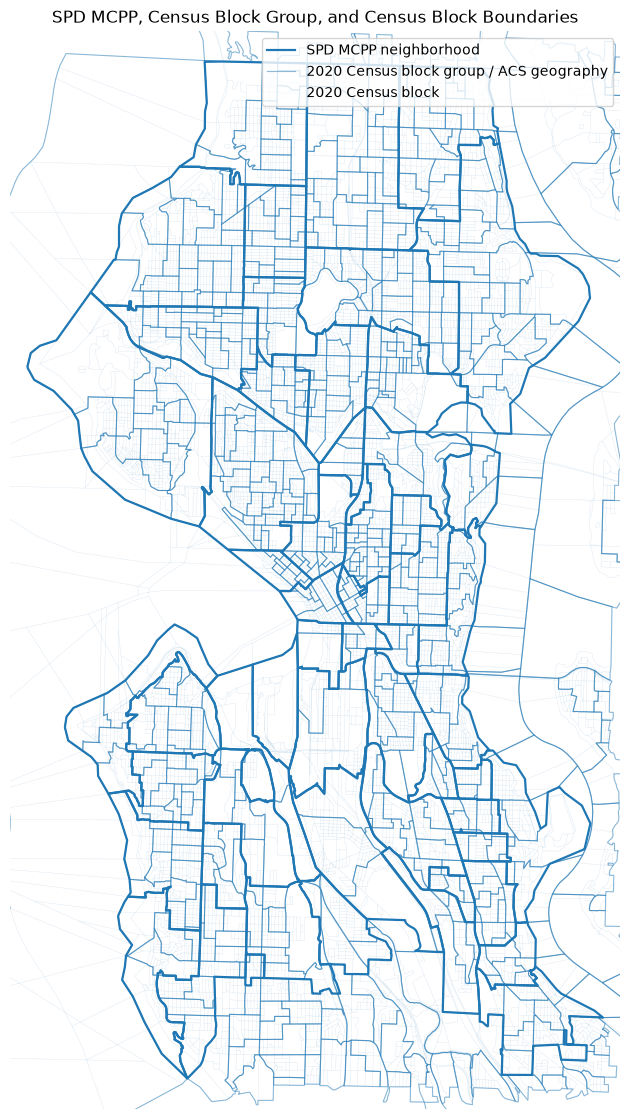

In [28]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


# -------------------------------------------------------------------
# VISUAL SETTINGS
#
# Change these values and rerun the cell.
# alpha: 0.0 = invisible, 1.0 = fully opaque
# -------------------------------------------------------------------

#BLOCK_ALPHA = 0.20
#BLOCK_GROUP_ALPHA = 0.50
#MCPP_ALPHA = 0.90

BLOCK_ALPHA = 0.10
BLOCK_GROUP_ALPHA = 0.50
MCPP_ALPHA = 1.00

BLOCK_LINEWIDTH = 0.25
BLOCK_GROUP_LINEWIDTH = 0.8
MCPP_LINEWIDTH = 1.6

FIGSIZE = (14, 14)


# -------------------------------------------------------------------
# Put all layers in the same projected CRS.
# -------------------------------------------------------------------

PLOT_CRS = "EPSG:2285"

mcpp_plot = (
    mcpp
    .to_crs(PLOT_CRS)
    .copy()
)

blocks_plot = (
    blocks
    .to_crs(PLOT_CRS)
    .copy()
)


# -------------------------------------------------------------------
# Reconstruct Census block-group boundaries.
#
# ACS population is supplied at the block-group level. We already have
# each block's parent bg_geoid, so dissolve blocks by bg_geoid to
# visualize the ACS source geography.
# -------------------------------------------------------------------

block_groups_plot = (
    blocks_plot[
        [
            "bg_geoid",
            "geometry",
        ]
    ]
    .dissolve(
        by="bg_geoid",
        as_index=False,
    )
)


# -------------------------------------------------------------------
# Limit display to the MCPP extent plus a little padding.
# -------------------------------------------------------------------

minx, miny, maxx, maxy = (
    mcpp_plot.total_bounds
)

x_padding = (maxx - minx) * 0.03
y_padding = (maxy - miny) * 0.03


# -------------------------------------------------------------------
# Plot.
# -------------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=FIGSIZE
)


# Census blocks
blocks_plot.boundary.plot(
    ax=ax,
    linewidth=BLOCK_LINEWIDTH,
    alpha=BLOCK_ALPHA,
)


# Census block groups / ACS geography
block_groups_plot.boundary.plot(
    ax=ax,
    linewidth=BLOCK_GROUP_LINEWIDTH,
    alpha=BLOCK_GROUP_ALPHA,
)


# SPD MCPP neighborhoods
mcpp_plot.boundary.plot(
    ax=ax,
    linewidth=MCPP_LINEWIDTH,
    alpha=MCPP_ALPHA,
)


ax.set_xlim(
    minx - x_padding,
    maxx + x_padding,
)

ax.set_ylim(
    miny - y_padding,
    maxy + y_padding,
)


ax.set_aspect("equal")

ax.set_title(
    "SPD MCPP, Census Block Group, and Census Block Boundaries"
)

ax.set_axis_off()


# -------------------------------------------------------------------
# Legend.
# -------------------------------------------------------------------

legend_handles = [
    Line2D(
        [0],
        [0],
        linewidth=MCPP_LINEWIDTH,
        alpha=MCPP_ALPHA,
        label="SPD MCPP neighborhood",
    ),
    Line2D(
        [0],
        [0],
        linewidth=BLOCK_GROUP_LINEWIDTH,
        alpha=BLOCK_GROUP_ALPHA,
        label="2020 Census block group / ACS geography",
    ),
    Line2D(
        [0],
        [0],
        linewidth=BLOCK_LINEWIDTH,
        alpha=BLOCK_ALPHA,
        label="2020 Census block",
    ),
]

ax.legend(
    handles=legend_handles,
    loc="upper right",
)

plt.show()